In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import pickle

In [2]:
import networkx as nx
nx.algorithms.d_separated = nx.algorithms.d_separation.is_d_separator
nx.d_separated = nx.algorithms.d_separation.is_d_separator
from dowhy import CausalModel

In [3]:
data = pd.read_pickle('../data-definitive/maize-soya-clean.pkl')

# DAG dataset

In [4]:
# We will add variables to the data_subset as we will need them
data_base = pd.DataFrame(index=data.index)
data_base['crop_name'] = data.mainharvestcrop
data_base['crop_maize'] = data_base.crop_name == 'maize'
data_base['outcome_prodkgha'] = data.maizeprodkg_ha.fillna(data.soyaprodkg_ha)
data_base['outcome_prodstd'] = (data.maizeprodkg_ha - data.maizeprodkg_ha.mean())/data.maizeprodkg_ha.std()
data_base['outcome_prodstd'] = data_base.outcome_prodstd.fillna(
    (data.soyaprodkg_ha - data.soyaprodkg_ha.mean())/data.soyaprodkg_ha.std()
)
data_base['treat_previousadvice'] = data.previousadvice == 'yes'
data_base['fieldsize_value'] = data.harvestarea_ha
# data[['maizeprodkg_ha']].copy()
# data_subset = data_subset.rename(columns={'maizeprodkg_ha': 'prodkgha'})

In [5]:
# Soil variables
soil_df = data[[
    'carbon_organic_mean_0_20', 'cation_exchange_capacity_mean_0_20', 'clay_content_mean_0_20', 
    'sand_content_mean_0_20', 'bulk_density_mean_0_20',
]].copy()
soil_df = soil_df.rename(columns={
    'carbon_organic_mean_0_20': 'soilfert_oc', 'cation_exchange_capacity_mean_0_20': 'soilfert_cec',
    'clay_content_mean_0_20': 'soilpp_clay', 'sand_content_mean_0_20': 'soilpp_sand', 
    'bulk_density_mean_0_20': 'soilpp_density', 
})
soilfert_vars = ['soilfert_oc'] # Soil potential fertility
soilpp_vars = ['soilpp_clay', 'soilpp_sand', 'soilpp_density'] # Soil physical properties

In [6]:
# Fertilizer variables
fert_df = data[['KGNbasal_ha', 'KGPbasal_ha']].copy()
fert_df.columns = ['fertN_basal', 'fertP_basal']

# Group fertilizer applications by timing and nutriend
for element in ('N', 'P'):
    for i in range(1, 4):
        tmp_df = data[[f'top{i}timing', f'KG{element}top{i}_ha']].copy()
        tmp_df[f'top{i}timing'] = tmp_df[f'top{i}timing'].replace({'tasseling': 'tasseling-silking', 'silking': 'tasseling-silking'})
        tmp_df = pd.pivot_table(
            tmp_df,
            values=f'KG{element}top{i}_ha', columns=f'top{i}timing',
            index='fieldID', fill_value=0, dropna=True
        )
        tmp_df = tmp_df.reindex(data.index)
        tmp_df.columns = tmp_df.columns.str.replace('-', '')
        tmp_df.columns = [f'fert{element}_{i}' for i in tmp_df.columns]
        for col in tmp_df.columns:
            if col in fert_df.columns:
                nan_rows = fert_df[col].isna() & tmp_df[col]
                fert_df[col] = fert_df[col].add(tmp_df[col], fill_value=0)
                fert_df.loc[nan_rows, col] = None
            else:
                fert_df[col] = tmp_df[col]

TIMINGS = [
    'basal', 'emergence', 'kneehigh', '56leaves', '810leaves',
    'tasselingsilking'
]
fert_df_alt = pd.DataFrame(index=fert_df.index)
# Create total N, P and timing dummy variables
for e in ('N', 'P'):
    # min_count=1 ensures that if at least 1 value is non-na, sum is computed and different from NaN
    fert_df_alt[f'fert{e}_total'] = fert_df[[f'fert{e}_{t}' for t in TIMINGS]].sum(axis=1, min_count=1)
    fert_df_alt[f'fert{e}_total'] = fert_df_alt[f'fert{e}_total'].where(lambda x: x<250, np.nan)
    fert_df_alt[[f'fert{e}_{t}' for t in TIMINGS]] = \
        fert_df[[f'fert{e}_{t}' for t in TIMINGS]].div(fert_df_alt[f'fert{e}_total'], axis=0)
    # fert_df_alt = fert_df_alt.dropna()

fert_df = fert_df_alt

fert_df.head()

,fertN_total,fertN_basal,fertN_emergence,fertN_kneehigh,fertN_56leaves,fertN_810leaves,fertN_tasselingsilking,fertP_total,fertP_basal,fertP_emergence,fertP_kneehigh,fertP_56leaves,fertP_810leaves,fertP_tasselingsilking
fieldID,,,,,,,,,,,,,,
nEDtlpqrbz,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
y0q886YDHg,71.755375,0.281250,0.0,0.718750,0.000000,0.000000,0.0,22.692637,1.0,0.0,0.0,0.0,0.0,0.0
NfyUaHgMdC,103.558950,0.226891,0.0,0.773109,0.000000,0.000000,0.0,26.420586,1.0,0.0,0.0,0.0,0.0,0.0
qfciDGlEMA,100.797568,0.200000,0.0,0.000000,0.511111,0.288889,0.0,22.668253,1.0,0.0,0.0,0.0,0.0,0.0
1LW4dvza0v,72.672534,0.200000,0.0,0.000000,0.511111,0.288889,0.0,16.343245,1.0,0.0,0.0,0.0,0.0,0.0


In [7]:
np.isclose(fert_df[[f'fertN_{t}' for t in TIMINGS]].sum(axis=1), 1).all(), \
    np.isclose(fert_df[[f'fertP_{t}' for t in TIMINGS]].sum(axis=1), 1).all()

(np.False_, np.False_)

In [8]:
# Map each dev stage to season fraction
stages_map = {
    'planting': (0, 10),
    'emergence': (0, 10),
    '5-6-leaves': (10, 30),
    'knee-high': (20, 40),
    '8-10-leaves': (30, 50),
    'tasseling-silking': (40, 100),
}

In [9]:
# Rain through the different stages
rain_dev_stages_df = pd.DataFrame(index=data.index)
rain_dev_stages_df['wthstage_rain0to10'] = data['0to10perc_season_prec']
rain_dev_stages_df['wthstage_rain10to30'] = data[['10to20perc_season_prec', '20to30perc_season_prec']].sum(axis=1)
rain_dev_stages_df['wthstage_rain20to40'] = data[['20to30perc_season_prec', '30to40perc_season_prec']].sum(axis=1)
rain_dev_stages_df['wthstage_rain30to50'] = data[['30to40perc_season_prec', '40to50perc_season_prec']].sum(axis=1)
rain_dev_stages_df['wthstage_rainp40to100'] = data[[f'{i}to{i+10}perc_season_prec' for i in range(40, 100, 10)]].sum(axis=1)
rain_dev_stages_df['wthstage_rainp0to60'] = data[[f'{i}to{i+10}perc_season_prec' for i in range(0, 60, 10)]].sum(axis=1)

In [10]:
# Seasonal weather
wth_season_df = data[['0to100perc_season_prec', '0to100perc_season_tmean']].copy()
wth_season_df.columns = ['wthseason_rain', 'wthseason_tmean']

In [11]:
# Single DF for weather
weather_df = pd.concat([rain_dev_stages_df, wth_season_df], axis=1)

In [12]:
# Phenology information
phenology_df = pd.DataFrame(index=data.index)
phenology_df['phenology_losdays'] = data['estimated_los']
# Standardize LOS by crop
tmp_series = data.estimated_los.where(data.mainharvestcrop == 'maize', np.nan)
phenology_df['phenology_losstd'] = (tmp_series - tmp_series.mean())/tmp_series.std()
tmp_series = data.estimated_los.where(data.mainharvestcrop == 'soya', np.nan)
phenology_df['phenology_losstd'] = phenology_df.phenology_losstd.fillna(
    (tmp_series - tmp_series.mean())/tmp_series.std()
)

In [13]:
# Varieties
variety_df = pd.DataFrame(index=data.index)
variety_df['variety_hybrid'] = ~data.maizevariety.isin(['LOCAL_VARIETY', 'CANNOT-REMEMBER-VARIETY', 'UNKNOWN_VARIETY'])
variety_df['variety_hybrid'] = ~variety_df.fillna(data.soyavariety.isin(['local', 'dontknow']))

#
variety_df['variety_recycled'] = data.maizerecycledseed == 'recycled'
variety_df['variety_recycled'] = variety_df.variety_recycled.fillna(
    data.maizerecycledseed.isin(['own', 'otherfarmer', 'relative_friend'])
)

In [14]:
# Crop history
# Define crop history with crop groups based on how they affect soil and managmeent
crop_groups = {
    'legume': ['beans', 'groundnuts', 'pigeonpea', 'soya'],
    'rootandtuber': ['cassava', 'roundpotatoes', 'sweetpotatoes'],
    'oilseed': ['sesame', 'sunflower']
}

def get_group_history(history:str):
    hist = {
        'history_maize': 'maize' in history,
        'history_nocrop': 'no_crop' in history
    }
    for group_name, crops in crop_groups.items():
        hist[f'history_{group_name}'] = any(map(lambda x: x in history, crops))
    return hist

history_df = pd.DataFrame.from_dict(data.crophistory.map(get_group_history).to_dict(), orient='index')

In [15]:
# External variables
external_df = data[['elevation', 'innacessibility_index']].copy()
external_df.columns = ['elevation_value', 'accessibility_rai']

In [16]:
# Residue will not be incorporated because it was measured for the end of the season, 
# therefore it could have not affected production. However it could serve as proxy,
# farmers doing it this time are more likely to do it every season
residue_df = pd.get_dummies(
    data.maizeresidues.where(
        data.maizeresidues.fillna(data.soyaresidues).isin(
            ['leave on field', 'burn', 'feed to animals', 'incorporate in the soil']
        ), 
        '0_other'
    ),
    prefix='residue_', drop_first=True, prefix_sep='' 
)
residue_df.columns = [col.replace(' ', '') for col in residue_df.columns]
residue_df['residue_onfield'] =  residue_df[['residue_incorporateinthesoil', 'residue_leaveonfield']].any(axis=1)

In [17]:
# Herbicide
herbicide_df = pd.DataFrame(index=data.index)
herbicide_df['herbicide_post'] = data.maizeherbicides.str.contains('post-emergence').astype(bool)
herbicide_df['herbicide_pre'] = data.maizeherbicides.str.contains('pre-emergence').astype(bool)
herbicide_df['herbicide_any'] = herbicide_df.any(axis=1)

In [18]:
# Manure
manure_df = pd.get_dummies(data.manurefreq, drop_first=False).iloc[:, [0, 2, 3]]
manure_df.columns = ['manure_everyseason', 'manure_oneinmany', 'manure_oneintwo']
manure_df['manure_any'] = manure_df.any(axis=1)
# Leave this to be the only manure variable
manure_df = manure_df[['manure_any']]

In [19]:
# Planting methods
# This could be used as a proxy of farmer knowledge. 
planting_df = pd.DataFrame(index=data.index)
planting_df = planting_df.join(pd.get_dummies(
    data.maizeplantingmethod.fillna(data.soyaplantingmethod), 
    drop_first=True, prefix='planting'
))
planting_df.columns = planting_df.columns.str.replace('-', '')

In [20]:
# Functions to calculate technology access and farming knowledge indices
def get_best_score(values, score_map, default_score=0):
    """
    Helper function to find the highest score for a farmer 
    across multiple related columns (e.g., maize and soya).
    """
    best_score = default_score
    for val in values:
        # Get the score for the value, or use default_score if
        # the value is nan or not a key in the map.
        score = score_map.get(val, default_score)
        if score > best_score:
            best_score = score
    return best_score

def calculate_knowledge_index(row):
    """
    Calculates the Farming Knowledge Index for a single farmer (row).
    The index is a score from 0 to 1.
    
    Variables used:
    - plantingmethod (maize, soya)
    - Pdeficiency (maize, soya)
    - residues (maize, soya)
    - inoculant_awareness (soya-specific)
    """
    
    total_score = 0
    max_score = 0
    
    # 1. Planting Method (Max 2 points)
    # 'string' (2) > 'plough-sowing' (1) > 'handhoe' (0)
    planting_map = {'string': 2, 'plough-sowing': 1, 'handhoe': 0, 'different': 0}
    planting_values = [row.get('maizeplantingmethod'), row.get('soyaplantingmethod')]
    total_score += get_best_score(planting_values, planting_map)
    max_score += 2 # Always applicable

    # 2. P Deficiency Diagnosis (Max 2 points)
    # 'yes'/'little' (2) > 'no' (1) > 'dontknow' (0)
    pdef_map = {'yes': 2, 'little': 2, 'no': 1, 'dontknow': 0}
    pdef_values = [row.get('maizePdeficiency'), row.get('soyaPdeficiency')]
    total_score += get_best_score(pdef_values, pdef_map)
    max_score += 2 # Always applicable

    # 3. Residue Management (Max 2 points)
    # 'incorporate'/'leave' (2) > 'feed'/'sell' (1) > 'burn' (0)
    residues_map = {
        'incorporate in the soil': 2, 
        'leave on field': 2, 
        'feed to animals': 1, 
        'sell': 1, 
        'move to another field': 1, 
        'burn': 0
    }
    # Use all available residue columns
    residue_values = [
        row.get('maizeresidues'), 
        row.get('soyaresidues'), 
        row.get('beansresidues'), 
        row.get('gnutsresidues')
    ]
    total_score += get_best_score(residue_values, residues_map)
    max_score += 2 # Always applicable

    # 4. Inoculant Awareness (Soya-specific, Max 2 points)
    # Check if the farmer is a soya grower
    is_soya_grower = row.get('mainharvestcrop') == 'soya'
    if is_soya_grower:
        max_score += 2 # Add to max score *only if* applicable
        if row.get('inoculant_awareness') == 'yes':
            total_score += 2
        # If 'no' or nan, score is 0 (already handled)

    # Calculate final normalized index
    if max_score == 0:
        return np.nan # Avoid division by zero
    
    return total_score / max_score

def calculate_tech_access_index(row):
    """
    Calculates the Technology Access Index for a single farmer (row).
    The index is a score from 0 to 1.
    
    Variables used:
    - fieldprep (maize, soya, beans, gnuts)
    - maizeharvestsheller (maize-specific)
    - inoculant_use (soya-specific)
    """
    
    total_score = 0
    max_score = 0

    # 1. Field Preparation (Max 2 points)
    # 'tractor' (2) > 'ploughcattle' (1) > 'handhoe' (0)
    fieldprep_map = {'tractor': 2, 'ploughcattle': 1, 'handhoe': 0, 'noplough': 0}
    prep_values = [
        row.get('maizefieldprep'), 
        row.get('beansfieldprep'), 
        row.get('soyafieldprep'), 
        row.get('gnutsfieldprep')
    ]
    total_score += get_best_score(prep_values, fieldprep_map)
    max_score += 2 # Always applicable

    # 2. Maize Harvest Sheller (Maize-specific, Max 2 points)
    is_maize_grower = row.get('mainharvestcrop') == 'maize'
    if is_maize_grower:
        max_score += 2 # Add to max score *only if* applicable
        if row.get('maizeharvestsheller') == 'yes':
            total_score += 2
            
    # 3. Inoculant Use (Soya-specific, Max 2 points)
    is_soya_grower = row.get('mainharvestcrop') == 'soya'
    if is_soya_grower:
        max_score += 2 # Add to max score *only if* applicable
        if row.get('inoculant_use') == 'yes':
            total_score += 2

    # Calculate final normalized index
    if max_score == 0:
        return np.nan # Avoid division by zero
        
    return total_score / max_score

In [21]:
tech_know_df = data.apply(calculate_knowledge_index, axis=1).to_frame(name='knowledge_index')
tech_know_df['techaccess_index'] = data.apply(calculate_tech_access_index, axis=1)

In [22]:
# Include a variable for neighborhood treatment assignment
gdf = gpd.read_file('../data-definitive/geo/points.geojson')
gdf = gdf.set_index('fieldID')
gdf['previousadvice'] = gdf.previousadvice == 'yes'

In [23]:
# Convert boolean 'previousadvice' to numeric (0 or 1) for calculation

gdf['previousadvice_numeric'] = gdf['previousadvice'].astype(int)
gdf['neighbor_previousadvice_weighted_avg'] = np.nan
radius_meters = 5000

for index, row in gdf.iterrows():
    current_geometry = row.geometry
    buffer_geom = current_geometry.buffer(radius_meters)
    possible_neighbors_mask = gdf.sindex.query(buffer_geom, predicate='intersects', output_format='dense')
    
    neighbors_df = gdf.iloc[possible_neighbors_mask]
    distances = neighbors_df.geometry.distance(current_geometry)
    valid_neighbors_distances = distances[(distances > 0) & (distances <= radius_meters)]
    
    if not valid_neighbors_distances.empty:
        neighbor_values = neighbors_df.loc[valid_neighbors_distances.index, 'previousadvice_numeric']
        weights = 1 / valid_neighbors_distances
        weighted_avg = (neighbor_values * weights).sum() / weights.sum()
        gdf.loc[index, 'neighbor_previousadvice_weighted_avg'] = weighted_avg

# The temporary 'previousadvice_numeric' column can be dropped if it's no longer needed
gdf = gdf.drop(columns=['previousadvice_numeric'])

In [24]:
neighbors_advice_df = gdf.neighbor_previousadvice_weighted_avg.fillna(0).to_frame(name='neighbor_previousadvice_avg')
neighbors_advice_df = neighbors_advice_df.loc[data_base.index]

In [25]:
# Join all data
data_subset = pd.concat([
    data_base, fert_df, wth_season_df, rain_dev_stages_df, soil_df, phenology_df,
    variety_df, history_df, external_df, tech_know_df, manure_df, neighbors_advice_df
], axis=1)
data_subset.shape

# Define DAG

The edges were defined after an iterative process with input from the stakeholder(s). The advice is mostly about nutrient management. They don't provide any advice on variety, but they have noticed that hybrid varieties are more prevalent among those that have received the advice. 

The only well known cause for the treatment assignment is the crop history. The extension agent is likely to be biased by their own personal context (e.g. give advice to farmers they know better), and the ease of access to the different fields. Therefore, socio-economic and spatially-variable factors could be an unintentional bias from the extension agent. 

## Edges

In [34]:
edges_list = []

# Define edges to the assignment
edges_list.extend([
    ('fieldHistory', 'previousAdvice'),
    ('accessibilityRAI', 'previousAdvice'),
    ('knowledge', 'previousAdvice'),
    ('techAccess', 'previousAdvice'),
    ('weather', 'previousAdvice'),
    ('soil', 'previousAdvice')
])
# Define edges from treatment
edges_list.extend([
    ('previousAdvice', 'outcome'), 
    ('previousAdvice', 'fertilizerTiming'), 
    ('previousAdvice', 'manure'),
])
# Edges from treatment spillover component
edges_list.extend([
    ('neighborsAdvice', 'outcome'), 
    ('neighborsAdvice', 'fertilizerTiming'), 
    ('neighborsAdvice', 'manure'), 
])
# Define edges to outcome
edges_list.extend([
    ('fertilizerAmount', 'outcome'),
    ('fertilizerTiming', 'outcome'),
    ('manure', 'outcome'),
    ('weather', 'outcome'),
    ('soil', 'outcome'),
    ('variety', 'outcome'),
    ('fieldHistory', 'outcome'),
    ('phenology', 'outcome'),
])
# Define edges definint other management components
edges_list.extend([
    ('knowledge', 'fertilizerAmount'),
    ('knowledge', 'fertilizerTiming'),
    ('knowledge', 'variety'),
    ('techAccess', 'fertilizerAmount'),
    ('techAccess', 'variety'),
    ('accessibilityRAI', 'variety'),
    ('accessibilityRAI', 'fertilizerAmount'),
    ('fieldHistory', 'fertilizerAmount'),
    ('crop', 'fertilizerAmount'),
    ('crop', 'fertilizerTiming'),
])
# Location related edges
edges_list.extend([
    ('elevation', 'weather'),
    ('elevation', 'soil'),
    ('accessibilityRAI', 'techAccess'),
])

# Phenology
edges_list.extend([
    ('weather', 'phenology'),
])

## Graph

In [35]:
causal_graph = nx.DiGraph(edges_list)
nodes_list = list(causal_graph.nodes())

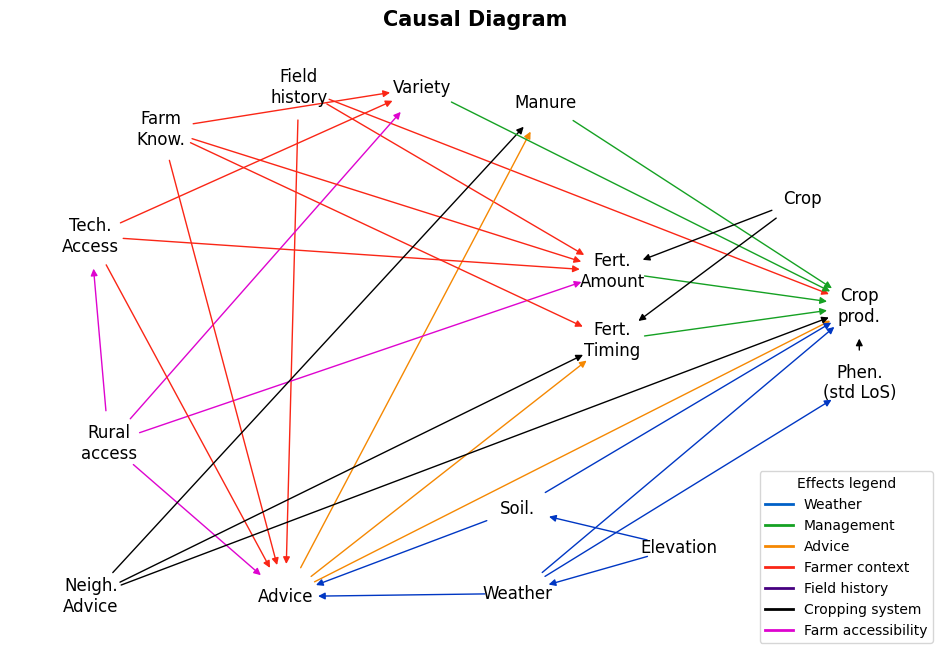

In [37]:
# As some factors are represented by multiple variables (e.g. Variety), 
# we will create a simplified graph that will be the one used when drawing.
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

labels={
    'accessibilityRAI': 'Rural\naccess', 'crop': 'Crop',
    'fertilizerTiming': 'Fert.\nTiming', 'fertilizerAmount': 'Fert.\nAmount', 
    'fieldHistory': 'Field\nhistory', 'manure': 'Manure',
    'outcome': 'Crop\nprod.', 'phenology': 'Phen.\n(std LoS)', 
    'soil': 'Soil.', 'elevation': 'Elevation',
    'techAccess': 'Tech.\nAccess', 'previousAdvice': 'Advice', 'variety': 'Variety',
    'weather': 'Weather', 'knowledge': 'Farm\nKnow.',
    'neighborsAdvice': 'Neigh.\nAdvice',
}

edge_colors = []
for cause, effect in causal_graph.edges:
    if cause in ['soil', 'weather', 'elevation']:
        edge_colors.append("#0037C3")
    elif cause in ('fertilizerAmount', 'fertilizerTiming', 'manure', 'variety'):
        edge_colors.append('#15a123')
    elif cause in ('previousAdvice', 'neighborAdvice'):
        edge_colors.append('#f58802')
    elif cause in ('techAccess', 'knowledge', 'fieldHistory'):
        edge_colors.append('#fa2616')
    elif cause in ('accessibilityRAI', 'elevation'):
        edge_colors.append("#de04cf")
    elif cause == 'history':
        edge_colors.append('#460080')
    else:
        edge_colors.append('k')

pos={
    'accessibilityRAI': (-3.8, -0.64), 'crop': (3.5, 2.55), 'cropgrowth': (2.1, 1.15),
    'fertilizerAmount': (1.5, 1.6), 'fertilizerTiming': (1.5, 0.7), 
    'knowledge': (-3.25, 3.46), 'fieldHistory': (-1.8, 4.0), 'manure': (0.8, 3.8),
    'outcome': (4.1, 1.15), 'phenology': (4.1, .15), 'elevation': (2.2, -2.),
    'soil': (0.5, -1.5), 
    'techAccess': (-3.99, 2.06), 'previousAdvice': (-1.94, -2.64), 'variety': (-.5, 4.),
    'weather': (0.5, -2.6), 'neighborsAdvice': (-3.99, -2.64),
}

nx.draw_networkx(
    causal_graph, ax=ax, node_size=2200, 
    labels=labels, 
    pos=pos,
    node_shape='o', node_color='#ffffff00', 
    # font_weight={node: 'bold' if node in adj_set_draw else 'normal' for node in labels.keys()},
    edge_color=edge_colors,
    # edgecolors=['k' if node in ('treat', 'outcome') else '#FFFFFF00' for node in causal_graph.nodes]
)
color_labels = [
    # ('#fa2616', 'Technology'), ('#785100', 'Soil'), 
    ('#0060c7', 'Weather'), ('#15a123', 'Management'), 
    ('#f58802', 'Advice'), ('#fa2616', 'Farmer context'), 
    ('#460080', 'Field history'), ('k', 'Cropping system'), 
    ('#de04cf', 'Farm accessibility')
]
ax.legend(handles=[
    mpl.lines.Line2D([], [], color=color, linestyle='-', linewidth=2, label=label)
    for color, label in color_labels
], loc='lower right', title='Effects legend')
ax.set_title('Causal Diagram', fontweight='bold', fontsize=15)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

# Identify backdoor adjustment set

In [38]:
from dowhy.causal_identifier import BackdoorAdjustment
treatment_name = "previousAdvice"
outcome_name = "outcome"
model_advice = CausalModel(
   data=pd.DataFrame(np.ones((1,len(nodes_list))), columns=nodes_list),
   treatment=treatment_name,
   outcome=outcome_name,
   graph="\n".join(nx.generate_gml(causal_graph))
)
identified_estimand_advice = model_advice.identify_effect(
   method_name=BackdoorAdjustment.BACKDOOR_MAX
)
identified_estimand_advice.get_backdoor_variables()

['soil',
 'neighborsAdvice',
 'variety',
 'fertilizerAmount',
 'fieldHistory',
 'phenology',
 'accessibilityRAI',
 'elevation',
 'knowledge',
 'crop',
 'techAccess',
 'weather']

In [89]:
treatment_name = "fertilizerAmount"
outcome_name = "outcome"
model_fert = CausalModel(
   data=pd.DataFrame(np.ones((1,len(nodes_list))), columns=nodes_list),
   treatment=treatment_name,
   outcome=outcome_name,
   graph="\n".join(nx.generate_gml(causal_graph))
)
identified_estimand_fert = model_fert.identify_effect(
   method_name=BackdoorAdjustment.BACKDOOR_MAX
)
identified_estimand_fert.get_backdoor_variables()

['phenology',
 'accessibilityRAI',
 'knowledge',
 'variety',
 'fertilizerTiming',
 'weather',
 'soil',
 'techAccess',
 'previousAdvice',
 'fieldHistory',
 'elevation',
 'neighborsAdvice',
 'crop',
 'manure']

In [ ]:
data_subset.to_pickle('../data-definitive/data-dag.pkl')

: 